# Lifetime Sparseness Analysis - Refactored

This notebook calculates lifetime sparseness for neuronal responses across stimuli and visualizes the results.

**Analysis Steps:**
1. Load and filter data for key stimuli
2. Calculate lifetime sparseness for each neuron
3. Perform statistical comparisons (Mann-Whitney U test vs OB)
4. Generate boxplot visualization
5. Generate brain projection visualization

## 1. Configuration and Parameters

In [1]:
# ============================================================================
# FILE PATHS - Modify these for your system
# ============================================================================

# Input files
REF_BRAIN_PATH = r'/Volumes/LaCie/area_masks/T_AVG_HuC.tif'
DATA_PATH = r'/Volumes/LaCie/larval_HuC/imaging/7dpf_wb_population_general_response_vector.h5'
NMLF_MASK_PATH = '/Volumes/LaCie/area_masks/area_masks_mapzebrain/nMLF.tiff'

# Output files
OUTPUT_CSV_PATH = '/Volumes/LaCie/larval_HuC/imaging/7dpf_area_sparseness_values.csv'
OUTPUT_BOXPLOT_PATH = "/Users/bethanjenkins/Documents/valence_paper_code/FiNA/figures/7dpf_lifetime_sparseness_avg_pvalues.svg"
OUTPUT_BRAINPLOT_PATH = "/Users/bethanjenkins/Documents/valence_paper_code/FiNA/figures/7dpf_lifetime_sparseness_plot.png"

In [2]:
# ============================================================================
# ANALYSIS PARAMETERS
# ============================================================================

# Stimuli to include in analysis
KEY_STIMULI = ('ade', 'pro_2.5mm', 'qui_2.5mm', 'cad_2.5mm', 'fex_1', 'kw', 'ph4.5')

# Statistical test parameters
REFERENCE_AREA = 'OB'  # Reference area for Mann-Whitney U comparisons
STATISTICAL_TEST = 'two-sided'  # Alternative hypothesis for Mann-Whitney U

# Brain plot parameters
BRAIN_PLOT_PERCENTAGE = 0.02  # Top and bottom 2% of neurons for brain visualization

# Boxplot parameters
AREAS_TO_PLOT = ['OE', 'OB', 'Pal', 'SubP', 'PT', 'dHb', 'vHb', 'POA', 'PTh', 'EmT', 'HI', 'HR']
AREA_ORDER = ['OE', 'OB', 'Pal', 'SubP', 'POA', 'PTh', 'EmT', 'dHb', 'vHb', 'PT', 'HR', 'HI']

In [3]:
# ============================================================================
# AREA NAME MAPPINGS
# ============================================================================
# Load in area dictionary with name and shorthand 
with open("/Volumes/LaCie/larval_HuC/imaging/brain_map_values/area_shorthand_dict.json", "r") as f:
    AREA_SHORTHAND = json.load(f)
print(f"✓ Area dictionary loaded: {len(AREA_SHORTHAND)} areas")

## 2. Import Libraries

In [4]:
import numpy as np 
from numpy import save
import pandas as pd 
from pathlib import Path
from skimage import io
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import json
import os
import itertools as it
import seaborn as sns
from collections import Counter

from statsmodels.stats.multicomp import pairwise_tukeyhsd
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec

from scipy.stats import f_oneway
from scipy.stats import chi2_contingency
from scipy.stats import pearsonr, linregress
from scipy.stats import mannwhitneyu
from numpy.polynomial.polynomial import Polynomial

## 3. Load Data

In [5]:
# Load reference brain image
ref_brain = io.imread(REF_BRAIN_PATH)

# Load fish data
fish_df = pd.read_hdf(DATA_PATH)

# Filter for key stimuli only
data = fish_df[fish_df['stimulus'].isin(KEY_STIMULI)]

# Create pivot table: neurons x (stimuli x trials)
resp_pop = data.pivot_table(
    index=('fish_id', 'neuron_id', 'coords_serialised', 'area'),
    columns=['stimulus', 'trial_number'], 
    values='resp'
)

print(f"Loaded data with {len(resp_pop)} neurons")
print(f"Stimuli: {KEY_STIMULI}")

Loaded data with 200116 neurons
Stimuli: ('ade', 'pro_2.5mm', 'qui_2.5mm', 'cad_2.5mm', 'fex_1', 'kw', 'ph4.5')


## 4. Optional to add a new area mask 

Reassign neurons that fall within the nMLF 3D mask to the 'nMLF' area.

In [6]:
def is_within_3d_mask(coordinates, mask):
    """Check if a neuron is within the area mask.
    
    Args:
        coordinates: 3D coordinates (z, y, x)
        mask: 3D binary mask array
        
    Returns:
        bool: True if coordinates fall within mask (mask > 0)
    """
    coordinates = np.array(coordinates, dtype=int)
    if coordinates.shape != (3,):
        return False
    
    z, y, x = coordinates
    depth, height, width = mask.shape
    
    if (0 <= z < depth) and (0 <= y < height) and (0 <= x < width):
        return mask[z, y, x] > 0
    return False


# Load nMLF mask
nMLF = io.imread(NMLF_MASK_PATH)

# Parse coordinates and reassign area if in nMLF
data['coords'] = data['coords_serialised'].apply(eval)
data['area'] = data.apply(
    lambda row: 'nMLF' if is_within_3d_mask(row['coords'], nMLF) else row['area'], 
    axis=1
)

print(f"nMLF neurons: {(data['area'] == 'nMLF').sum()}")

/var/folders/jq/73zm0hgn5pv677grmxk938cm0000gn/T/ipykernel_24272/433362609.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['coords'] = data['coords_serialised'].apply(eval)
/var/folders/jq/73zm0hgn5pv677grmxk938cm0000gn/T/ipykernel_24272/433362609.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['area'] = data.apply(


nMLF neurons: 14469


## 5. Calculate Lifetime Sparseness

Lifetime sparseness measures how selectively a neuron responds across different stimuli.
- Value close to 0: responds similarly to all stimuli (broadly tuned)
- Value close to 1: responds strongly to few stimuli (narrowly tuned)

In [15]:
def lifetime_sparseness(vector):
    """Calculate the lifetime sparseness of a neuron's responses across stimuli.
    
    Handles negative values by shifting the entire vector by its minimum value.
    
    Args:
        vector (numpy.array): 1D array of neuron's responses to different stimuli.
        
    Returns:
        float: Lifetime sparseness value (0 = broadly tuned, 1 = narrowly tuned)
    """
    n = len(vector)
    if n == 0:
        return 0  # Avoid division by zero if vector is empty

    # Option 1: Shift the vector by the minimum value to make all elements non-negative
    min_value = np.min(vector)
    resp_vector = vector - min_value
    
    # Option 2: Replace negative values with zero (COMMENTED OUT)
    # resp_vector = np.where(vector < 0, 0, vector)

    # Calculate the sum and sum of squares of the response vector
    sum_r = np.sum(resp_vector)
    sum_r_squared = np.sum(resp_vector**2)

    # Check for cases where the sum of squares is zero
    if sum_r_squared == 0 or sum_r == 0:
        return 0  # Return 0 to avoid division by zero

    # Calculate lifetime sparseness
    sparseness = 1 - (sum_r**2 / (n * sum_r_squared))
    return sparseness

In [16]:
# Create population vector: average response per stimulus for each neuron
selected_pop_vec = []
for stimi in KEY_STIMULI:
    # Average across trials for this stimulus
    stimuli_vec = np.mean(resp_pop[stimi].values, axis=1)
    selected_pop_vec.append(stimuli_vec)

population_vector = np.asarray(selected_pop_vec)
print(f"Population vector shape: {population_vector.shape}")
print(f"  (stimuli × neurons) = ({len(KEY_STIMULI)} × {population_vector.shape[1]})")

Population vector shape: (7, 200116)
  (stimuli × neurons) = (7 × 200116)


In [18]:
# Apply lifetime sparseness calculation to each neuron (column)
sparseness_values = np.apply_along_axis(lifetime_sparseness, 0, population_vector)

# Add to dataframe
df = resp_pop.copy()
df['sparseness_values'] = sparseness_values
df = df.reset_index()

# Parse coordinates from serialized format
df['coords_serialised'] = df['coords_serialised'].astype(str)
df['coords'] = df['coords_serialised'].apply(lambda x: np.asarray(json.loads(x)))
df.drop('coords_serialised', axis=1, inplace=True)

# Remove any neurons with missing sparseness values
df = df.dropna(subset=[('sparseness_values', '')])

values_for_brain_map = df.copy()

values_for_brain_map.rename(columns={"area": "area_names", "sparseness_values": "values"}, inplace=True)

print(f"Calculated sparseness for {len(df)} neurons")
print(f"Sparseness range: {df['sparseness_values'].min():.3f} - {df['sparseness_values'].max():.3f}")

Calculated sparseness for 200116 neurons
Sparseness range: 0.143 - 0.851


/var/folders/jq/73zm0hgn5pv677grmxk938cm0000gn/T/ipykernel_24272/3240152304.py:12: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df.drop('coords_serialised', axis=1, inplace=True)


In [ ]:
# Save full neuron-level sparseness data
values_for_brain_map.to_csv(OUTPUT_CSV_PATH, index=False)
print(f"Saved neuron-level data to: {OUTPUT_CSV_PATH}")

## 6. Aggregate by Area and Fish

Calculate average sparseness per fish per brain area for statistical testing.

In [19]:
# Map area names to shorthand codes
df.loc[:, 'area'] = df['area'].map(AREA_SHORTHAND_DICT)
areas = df['area'].unique()

# Clean fish IDs (remove '_fb' and '_hb' suffixes)
df['fish_id'] = df['fish_id'].str.replace('_fb', '', regex=True).str.replace('_hb', '', regex=True)

# Calculate average lifetime sparseness for each fish in each area
area_fish_lifetime_sparseness = df.groupby(['area', 'fish_id'])['sparseness_values'].mean().reset_index()

print(f"Areas found: {len(areas)}")
print(f"Fish per area (avg): {area_fish_lifetime_sparseness.groupby('area')['fish_id'].nunique().mean():.1f}")

Areas found: 39
Fish per area (avg): 9.8


## 7. Statistical Analysis

Perform Mann-Whitney U test comparing each area to the reference area (OB).

In [20]:
# Get reference area data
ob_data = area_fish_lifetime_sparseness[
    area_fish_lifetime_sparseness['area'] == REFERENCE_AREA
]['sparseness_values']

# Calculate p-values for all areas vs reference
pvals = {}
for area in areas:
    if area == REFERENCE_AREA:
        continue  # Skip reference vs reference
    
    area_data = area_fish_lifetime_sparseness[
        area_fish_lifetime_sparseness['area'] == area
    ]['sparseness_values']
    
    if len(area_data) > 0:
        stat, p = mannwhitneyu(ob_data, area_data, alternative=STATISTICAL_TEST)
        pvals[area] = p

# Add p-values to dataframe
pval_df = pd.DataFrame.from_dict(pvals, orient='index', columns=['p_value']).reset_index()
pval_df = pval_df.rename(columns={'index': 'area'})
area_fish_lifetime_sparseness = area_fish_lifetime_sparseness.merge(pval_df, on='area', how='left')

print(f"Significant areas (p < 0.05): {sum(pval_df['p_value'] < 0.05)}")
print(f"Highly significant areas (p < 0.001): {sum(pval_df['p_value'] < 0.001)}")

Significant areas (p < 0.05): 32
Highly significant areas (p < 0.001): 21


In [21]:
# Create summary statistics table
summary = (
    area_fish_lifetime_sparseness
    .groupby('area')
    .agg(
        n_fish=('fish_id', 'nunique'),
        mean=('sparseness_values', 'mean'),
        std=('sparseness_values', 'std'),
        p_value=('p_value', 'first')  # p_value is same for all rows in an area
    )
    .reset_index()
)

# Add test name
summary['test'] = 'Mann-Whitney U'

# Reorder columns
summary = summary[['area', 'n_fish', 'mean', 'std', 'test', 'p_value']]

display(summary)

,area,n_fish,mean,std,test,p_value
0,Cb,10,0.367817,0.014299,Mann-Whitney U,0.000183
1,EmT,10,0.434026,0.032167,Mann-Whitney U,0.427355
2,HC,6,0.368144,0.051705,Mann-Whitney U,0.031219
3,HI,10,0.366074,0.013643,Mann-Whitney U,0.000183
4,HR,10,0.387125,0.026711,Mann-Whitney U,0.000330
5,IO,9,0.372110,0.029073,Mann-Whitney U,0.000703
6,IPN,10,0.361831,0.017579,Mann-Whitney U,0.000183
7,LC,10,0.392076,0.055277,Mann-Whitney U,0.031209
8,LRN,9,0.396817,0.094232,Mann-Whitney U,0.236445
9,NI,10,0.392326,0.023460,Mann-Whitney U,0.000440


## 8. Boxplot Visualization

Create boxplot showing sparseness distribution across selected brain areas.

In [22]:
def plot_sparseness_boxplot(data, areas_to_plot, area_order, pvals):
    """Create boxplot of lifetime sparseness by brain area.
    
    Args:
        data: DataFrame with columns ['area', 'sparseness_values']
        areas_to_plot: List of area codes to include
        area_order: List defining the x-axis order
        pvals: Dict mapping area codes to p-values
        
    Returns:
        matplotlib.figure.Figure
    """
    # Area color palette
    palette = {
        "OB": "#16327F", "OE": "#000000", "Pal": "#377DA3", "SubP": "#58C8FE",
        "PT": "#EF4066", "dHb": "#663200", "vHb": "#933264", "POA": "#8C8C00",
        "PTh": "#1E7F1D", "EmT": "#6CDA60", "HR": "#D9D900", "HI": "#EB7F25"
    }
    
    # Filter data
    plot_data = data[data['area'].isin(areas_to_plot)]
    
    # Create figure
    fig = plt.figure(figsize=(11, 6))
    
    # Draw boxplot
    ax = sns.boxplot(
        data=plot_data,
        x='area',
        y='sparseness_values',
        order=area_order,
        color="white",
        width=0.5,
        showcaps=False,
        showfliers=False,
        boxprops={'edgecolor': 'black', 'linewidth': 4},
        whiskerprops={'color': 'black', 'linewidth': 4},
        capprops={'color': 'black', 'linewidth': 4},
        medianprops={'color': '#8A02B7', 'linewidth': 4}
    )
    
    # Get plotted areas (may exclude missing)
    plotted_areas = [area for area in area_order if area in plot_data['area'].unique()]
    
    # Recolor boxes and lines
    lines = ax.get_lines()
    num_boxes = len(plotted_areas)
    num_lines_per_box = len(lines) // num_boxes
    
    for i, area in enumerate(plotted_areas):
        color = palette[area]
        
        # Update box border
        box = ax.patches[i]
        box.set_edgecolor(color)
        box.set_linewidth(3)
        box.set_facecolor("white")
        
        # Update whiskers
        for line in lines[i * num_lines_per_box : i * num_lines_per_box + 2]:
            line.set_color(color)
            line.set_linewidth(3)
        
        # Update caps
        for line in lines[i * num_lines_per_box + 2 : i * num_lines_per_box + 4]:
            line.set_color(color)
            line.set_linewidth(3)
        
        # Update median
        if i * num_lines_per_box + 4 < len(lines):
            median = lines[i * num_lines_per_box + 4]
            median.set_color("#8A02B7")
            median.set_linewidth(3)
    
    # Color x-axis labels to match boxes
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=24)
    for label, area in zip(ax.get_xticklabels(), plotted_areas):
        label.set_color(palette[area])
    
    # Add scatter points (jittered)
    for i, area in enumerate(plotted_areas):
        area_data = plot_data[plot_data['area'] == area]
        jittered_x = [i + 0.4 for _ in range(len(area_data))]
        plt.scatter(jittered_x, area_data['sparseness_values'], color='black', s=30)
    
    # Add significance annotations
    y_pos = 0.6
    for i, area in enumerate(area_order):
        if area == REFERENCE_AREA:
            continue
        
        p_val = pvals.get(area, 1.0)
        
        # Determine significance label
        if p_val < 0.001:
            significance = '***'
        elif p_val < 0.01:
            significance = '**'
        elif p_val < 0.05:
            significance = '*'
        else:
            significance = 'ns'
        
        if area in plotted_areas:
            plt.text(i, y_pos, significance, ha='center', 
                    fontsize=20, color='black', weight='bold')
    
    # Styling
    plt.xlabel('', fontsize=14)
    plt.ylabel('Sparseness', fontsize=35)
    plt.xticks(rotation=45, fontsize=35)
    plt.yticks([0.2, 0.3, 0.4, 0.5, 0.6], fontsize=28)
    plt.ylim(0.3, 0.6)
    
    # Clean up spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)
    ax.tick_params(width=2)
    
    plt.tight_layout()
    
    return fig

/var/folders/jq/73zm0hgn5pv677grmxk938cm0000gn/T/ipykernel_24272/4109114190.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=24)


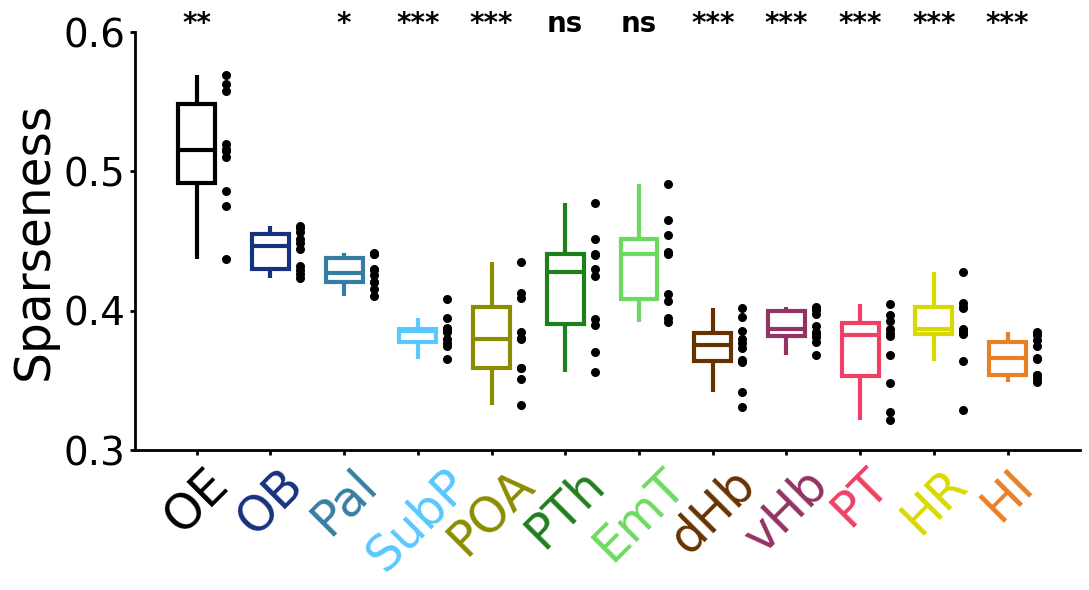

In [23]:
# Generate boxplot
fig_boxplot = plot_sparseness_boxplot(
    area_fish_lifetime_sparseness, 
    AREAS_TO_PLOT, 
    AREA_ORDER, 
    pvals
)

plt.show()

# Uncomment to save
# fig_boxplot.savefig(OUTPUT_BOXPLOT_PATH, format="svg", dpi=300, bbox_inches="tight")

## 9. Brain Projection Visualization

Show spatial distribution of most and least sparse neurons in brain projections.

In [24]:
def select_extreme_neurons(data, percentage=BRAIN_PLOT_PERCENTAGE):
    """Select neurons with extreme sparseness values.
    
    Args:
        data: DataFrame with 'sparseness_values' column
        percentage: Fraction of top and bottom neurons to select (default: 0.02 = 2%)
        
    Returns:
        DataFrame with top and bottom percentage of neurons
    """
    df_sorted = data.sort_values(by=('sparseness_values', ''), ascending=True)
    df_sorted = df_sorted.dropna(subset=[('area', '')])
    
    count = int(len(df_sorted) * percentage)
    
    least_sparse = df_sorted.head(count)
    most_sparse = df_sorted.tail(count)
    
    selected = pd.concat([least_sparse, most_sparse], ignore_index=True)
    
    print(f"Selected {len(selected)} neurons ({percentage*100:.1f}% from each end)")
    print(f"  Least sparse range: {least_sparse['sparseness_values'].min():.3f} - {least_sparse['sparseness_values'].max():.3f}")
    print(f"  Most sparse range: {most_sparse['sparseness_values'].min():.3f} - {most_sparse['sparseness_values'].max():.3f}")
    
    return selected

In [25]:
def plot_sparseness_brain(ref_brain, data, cmap):
    """Plot neuron sparseness on brain projections.
    
    Creates horizontal (top) and sagittal (bottom) projections of the brain
    with neurons colored by their sparseness values.
    
    Args:
        ref_brain: 3D numpy array of reference brain
        data: DataFrame with 'coords' and 'sparseness_values' columns
        cmap: Matplotlib colormap
        
    Returns:
        matplotlib.figure.Figure
    """
    fig = plt.figure(figsize=(6, 8.2))
    gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1])
    gs.update(hspace=-0.5)
    
    ax_horizontal = fig.add_subplot(gs[0])
    ax_sagittal = fig.add_subplot(gs[1])
    
    # Extract coordinates and sparseness values
    coords = np.vstack(data['coords'])
    sparseness = data['sparseness_values']
    
    # Horizontal projection (mean along z-axis, rotated 90° CCW)
    proj_horizontal = np.nanmean(ref_brain, axis=0)
    proj_horizontal = np.rot90(proj_horizontal, k=1)
    ax_horizontal.imshow(proj_horizontal, cmap='gray_r', alpha=0.5, origin='lower')
    
    # Transform coordinates for rotated projection
    rotated_x = coords[:, 1]  # Y becomes X
    rotated_y = proj_horizontal.shape[0] - coords[:, 2]  # Flip Z to Y
    
    ax_horizontal.scatter(rotated_x, rotated_y, c=sparseness, cmap=cmap,
                         s=10, edgecolor='none', alpha=0.5)
    ax_horizontal.axis('off')
    ax_horizontal.set_aspect('equal')
    ax_horizontal.set_xlim(0, proj_horizontal.shape[1])
    ax_horizontal.set_ylim(0, proj_horizontal.shape[0])
    
    # Add scale bar to horizontal projection
    ax_horizontal.hlines(
        y=proj_horizontal.shape[0] - 20,
        xmin=20,
        xmax=120,
        color='black',
        linewidth=3
    )
    
    # Sagittal projection (mean along x-axis)
    proj_sagittal = np.nanmean(ref_brain, axis=2)
    ax_sagittal.imshow(proj_sagittal, cmap='gray_r', alpha=0.5, origin='lower')
    
    ax_sagittal.scatter(coords[:, 1], coords[:, 0], c=sparseness, cmap=cmap,
                       s=10, edgecolor='none', alpha=0.5)
    ax_sagittal.axis('off')
    ax_sagittal.set_aspect('equal')
    ax_sagittal.set_xlim(0, proj_sagittal.shape[1])
    ax_sagittal.set_ylim(0, proj_sagittal.shape[0])
    
    # Add colorbar
    cbar_ax = fig.add_axes([0.88, 0.4, 0.02, 0.3])
    cbar = fig.colorbar(ax_horizontal.collections[0], cax=cbar_ax)
    cbar.set_label("Sparseness", fontsize=23)
    cbar.ax.tick_params(labelsize=23)
    
    return fig

Selected 7554 neurons (2.0% from each end)
  Least sparse range: 0.143 - 0.178
  Most sparse range: 0.723 - 0.851


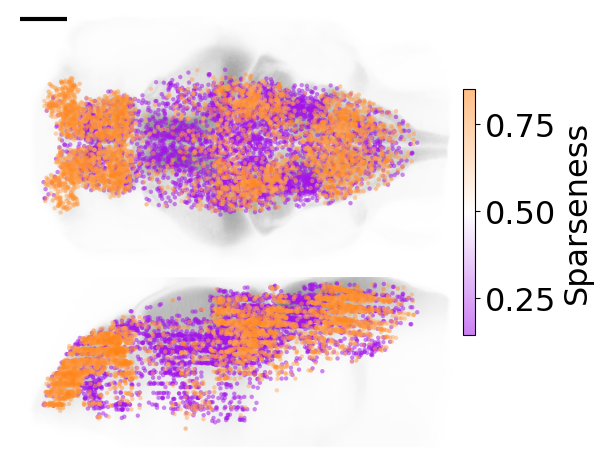

In [26]:
# Create custom colormap
bright_purple = "#9b00e8"
bright_orange = "#ff7f0e"
custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    "BrightPuOr", 
    [bright_purple, "white", bright_orange]
)

# Select extreme neurons for visualization
sparseness_subset = select_extreme_neurons(df)

# Generate brain plot
fig_brain = plot_sparseness_brain(ref_brain, sparseness_subset, custom_cmap)
plt.show()

# Uncomment to save
# fig_brain.savefig(OUTPUT_BRAINPLOT_PATH, format="png", dpi=300, bbox_inches="tight")

## 10. Summary Statistics (Optional)

Display summary statistics for specific areas of interest.

In [ ]:
# Compute summary statistics for plotted areas
area_lifetime_sparseness = area_fish_lifetime_sparseness[
    area_fish_lifetime_sparseness['area'].isin(AREAS_TO_PLOT)
]

stats_ordered = (
    area_lifetime_sparseness
    .groupby('area')['sparseness_values']
    .agg(['mean', 'median', 'std'])
    .reset_index()
)

# Reorder by area order
stats_ordered['area'] = pd.Categorical(
    stats_ordered['area'], 
    categories=AREA_ORDER, 
    ordered=True
)
stats_ordered = stats_ordered.sort_values('area')

print("\nSummary Statistics by Area:")
display(stats_ordered)

## Analysis Complete

**Outputs:**
- Neuron-level sparseness data saved to CSV
- Statistical comparisons vs OB completed
- Boxplot visualization generated
- Brain projection visualization generated